# E-Commerce Data Analysis

Cleaning and analyzing the UCI Online Retail dataset (~540K
transactions from a UK-based online retailer) with pandas, then
visualizing revenue by country.

**roadmap.sh project:**
https://roadmap.sh/projects/ecommerce-data-analysis

## Setup & Imports

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
Path("outputs").mkdir(exist_ok=True)

## Data Acquisition

Source: [UCI Machine Learning Repository â€” Online Retail](
https://archive.ics.uci.edu/ml/datasets/online+retail)

`data/online_retail.xlsx` is gitignored; see the README for the
download link.

In [2]:
raw = pd.read_excel("data/online_retail.xlsx")
raw.shape

(541909, 8)

## Sampling

The full dataset has ~540K rows. Per the project spec, sample 10%
for manageability (fixed seed for reproducibility).

In [3]:
df = raw.sample(frac=0.1, random_state=42).reset_index(drop=True)
df.shape

(54191, 8)

## Data Cleaning

- Drop rows with nulls (mostly missing `CustomerID`)
- Correct dtypes: `InvoiceDate` -> datetime, `CustomerID` -> int
- Filter out returns (`InvoiceNo` starting with `C`, or negative
  `Quantity`) and complimentary items (`UnitPrice` <= 0)

In [4]:
df.isna().sum()

InvoiceNo          0
StockCode          0
Description      149
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     13640
Country            0
dtype: int64

In [5]:
df = df.dropna(subset=["CustomerID", "Description"]).copy()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["CustomerID"] = df["CustomerID"].astype(int)

is_return = df["InvoiceNo"].str.startswith("C")
df = df[~is_return]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df.shape

(39635, 8)

## Revenue Column

`Revenue = Quantity * UnitPrice`

In [6]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df[["InvoiceNo", "Description", "Quantity", "UnitPrice",
    "Revenue"]].head()

,InvoiceNo,Description,Quantity,UnitPrice,Revenue
0,555200,HANGING JAM JAR T-LIGHT HOLDER,24,0.85,20.40
1,554974,GOLD FISHING GNOME,4,6.95,27.80
2,550972,SET/6 RED SPOTTY PAPER CUPS,4,0.65,2.60
3,576652,PACK 3 BOXES CHRISTMAS PANETTONE,3,1.95,5.85
4,546157,RETROSPOT LAMP,2,9.95,19.90


## Top 10 Countries by Total Revenue

In [7]:
top_countries = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_countries

Country
United Kingdom    768682.561
Netherlands        27435.830
EIRE               24340.420
France             23606.730
Germany            22389.510
Australia          12429.990
Spain               5600.900
Switzerland         5383.190
Belgium             3593.510
Portugal            3244.310
Name: Revenue, dtype: float64

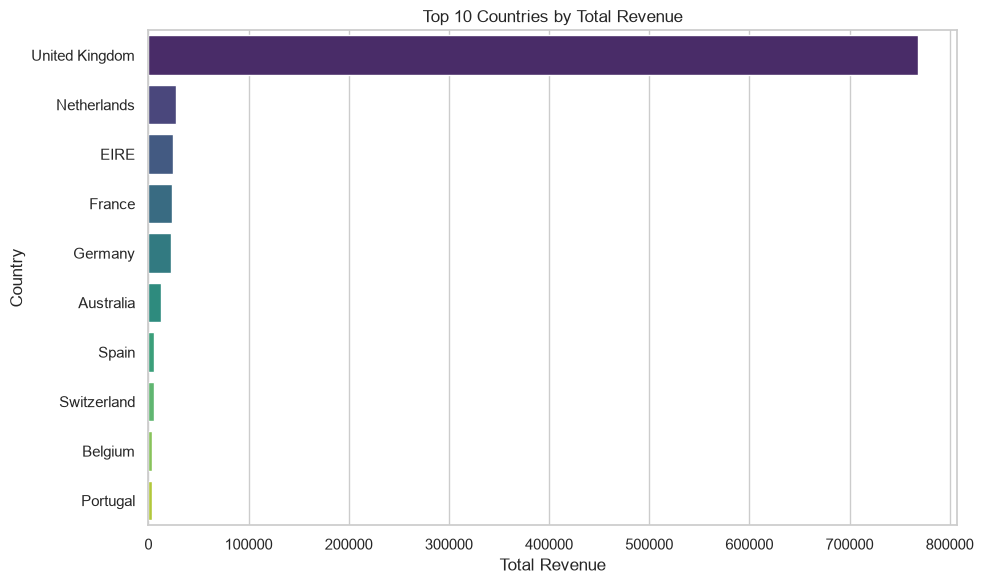

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Total Revenue")
ax.set_ylabel("Country")
ax.set_title("Top 10 Countries by Total Revenue")
fig.tight_layout()
fig.savefig("outputs/top_10_countries_revenue.png", dpi=150)
plt.show()

## Findings

- After cleaning (dropping nulls, removing returns and
  complimentary/zero-price items), the 10% sample retains the large
  majority of transactions as genuine sales.
- The **United Kingdom** dominates total revenue by a wide margin,
  consistent with the retailer's home market.
- The remaining top 10 are a mix of European markets (e.g.
  Netherlands, EIRE, Germany, France), reflecting the retailer's
  primary export destinations.